# Reading Order as an Inductive Bias — 5-Way Comparison (LSTM, 20-Way Coarse CIFAR-100)

Five LSTMs, **identical in every way** (same images, split, architecture, weight initialization, and
schedule) except for the order pixels are fed in. The orderings span maximum→minimum spatial locality:

- **row-major** — read row by row (the original).
- **spiral** — outside→center concentric rings.
- **hilbert** — a space-filling curve; neighbors stay adjacent (most locality).
- **morton** (Z-order) — a space-filling curve *with* long diagonal jumps (a diagnostic: isolates
  whether locality matters, vs merely "not row-major").
- **random** — a fixed random permutation; no locality (the floor).

Each ordering is just a permutation of the 1,024 pixels, reshaped to the same `(32, 96)` tensor, so any
difference in the results is attributable to reading order alone. Self-contained; runs top-to-bottom in
Colab. **It trains five models** — budget ~10–15 min on a T4 (lower `SUBSET` to go faster).


## 1. Setup

In [1]:
import subprocess
import sys


def _ensure(module_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or module_name])


_ensure("datasets")
_ensure("sklearn", "scikit-learn")
_ensure("matplotlib")

In [2]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, top_k_accuracy_score

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("tensorflow:", tf.__version__)

tensorflow: 2.20.0


In [3]:
# --- Run configuration (trains FIVE models, one per reading order) ---
NUM_CLASSES = 20          # CIFAR-100 coarse superclasses
SUBSET      = 20000       # train-set size per model. None = full 50k; ~5000 to iterate fast.
EPOCHS      = 30          # EarlyStopping usually stops earlier
BATCH       = 128
HIDDEN      = 128
DROPOUT     = 0.3
LR          = 1e-3
print(f"classes={NUM_CLASSES}  subset={SUBSET}  epochs={EPOCHS}  batch={BATCH}  (x5 models)")

classes=20  subset=20000  epochs=30  batch=128  (x5 models)


## 2. Load CIFAR-100

In [4]:
ds = load_dataset("uoft-cs/cifar100")
train_split, test_split = ds["train"], ds["test"]
coarse_names = train_split.features["coarse_label"].names


def split_to_arrays(split):
    images = np.stack([np.asarray(row["img"].convert("RGB"), dtype=np.uint8) for row in split])
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, coarse


train_images, train_coarse = split_to_arrays(train_split)
test_images, test_coarse = split_to_arrays(test_split)
print("train:", train_images.shape, "| test:", test_images.shape, "| classes:", len(coarse_names))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train: (50000, 32, 32, 3) | test: (10000, 32, 32, 3) | classes: 20


## 3. Look at the Data

Coarse CIFAR-100 is balanced (~2,500 per superclass), so accuracy is meaningful; random = 1/20 = 5%.

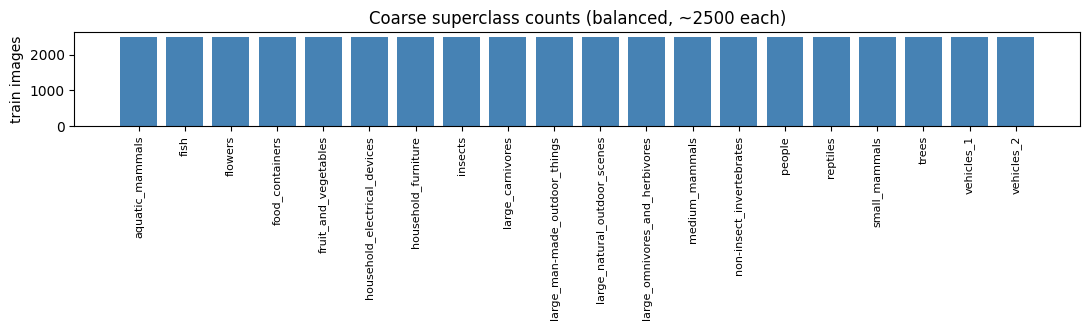

In [5]:
counts = np.bincount(train_coarse, minlength=NUM_CLASSES)
plt.figure(figsize=(11, 3.4))
plt.bar(range(NUM_CLASSES), counts, color="steelblue")
plt.xticks(range(NUM_CLASSES), coarse_names, rotation=90, fontsize=8)
plt.ylabel("train images"); plt.title(f"Coarse superclass counts (balanced, ~{counts.mean():.0f} each)")
plt.tight_layout(); plt.show()

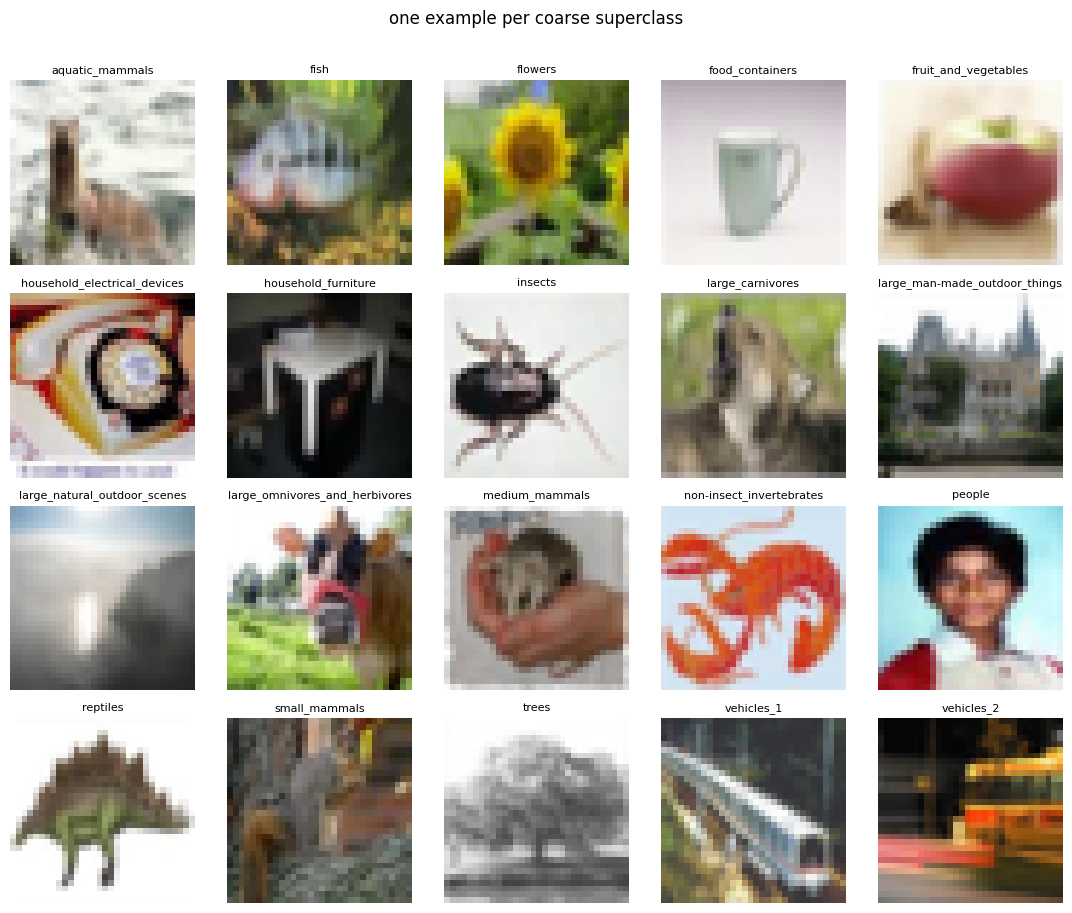

In [6]:
fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for k, ax in enumerate(axes.ravel()):
    j = int(np.flatnonzero(train_coarse == k)[0])
    ax.imshow(train_images[j]); ax.set_title(coarse_names[k], fontsize=8); ax.axis("off")
plt.suptitle("one example per coarse superclass", y=1.01); plt.tight_layout(); plt.show()

## 4. Stratified Subset + Split (shared by all five models)

In [7]:
def stratified_subset(images, labels, *, subset_size, seed):
    if subset_size is None or subset_size >= labels.shape[0]:
        return images, labels
    rng = np.random.default_rng(seed)
    parts = []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        n_cls = min(max(1, round(subset_size * idx.size / labels.shape[0])), idx.size)
        parts.append(rng.choice(idx, size=n_cls, replace=False))
    sel = np.concatenate(parts)
    if sel.shape[0] > subset_size:
        sel = rng.choice(sel, size=subset_size, replace=False)
    rng.shuffle(sel)
    return images[sel], labels[sel]


def stratified_train_val_split(images, labels, *, val_fraction=0.1, seed=42):
    rng = np.random.default_rng(seed)
    tr, va = [], []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        rng.shuffle(idx)
        n_val = min(max(1, round(len(idx) * val_fraction)), max(len(idx) - 1, 1))
        va.append(idx[:n_val]); tr.append(idx[n_val:])
    tr, va = np.concatenate(tr), np.concatenate(va)
    rng.shuffle(tr); rng.shuffle(va)
    return images[tr], labels[tr], images[va], labels[va]

## 5. The Five Reading Orders

Each ordering is a permutation of the 1,024 flat pixel indices (`row*32 + col`). `to_sequence(images,
index)` reorders the pixels and reshapes to `(N, 32, 96)` — 32 timesteps of 32 pixels each. Everything
downstream is shared; the ordering is the only thing that changes.


In [8]:
N = 32

def build_spiral_index(n):
    order = []; top, bottom, left, right = 0, n - 1, 0, n - 1
    while top <= bottom and left <= right:
        for c in range(left, right + 1): order.append(top * n + c)
        top += 1
        for r in range(top, bottom + 1): order.append(r * n + right)
        right -= 1
        if top <= bottom:
            for c in range(right, left - 1, -1): order.append(bottom * n + c)
            bottom -= 1
        if left <= right:
            for r in range(bottom, top - 1, -1): order.append(r * n + left)
            left += 1
    return np.asarray(order, dtype=np.int64)


def _hilbert_rot(s, x, y, rx, ry):
    if ry == 0:
        if rx == 1:
            x, y = s - 1 - x, s - 1 - y
        x, y = y, x
    return x, y


def hilbert_d2xy(n, d):
    x = y = 0; t = d; s = 1
    while s < n:
        rx = 1 & (t // 2); ry = 1 & (t ^ rx)
        x, y = _hilbert_rot(s, x, y, rx, ry)
        x += s * rx; y += s * ry; t //= 4; s *= 2
    return x, y


def build_hilbert_index(n):
    out = []
    for d in range(n * n):
        x, y = hilbert_d2xy(n, d)
        out.append(y * n + x)
    return np.asarray(out, dtype=np.int64)


def build_morton_index(n, bits=5):
    out = []
    for d in range(n * n):
        x = y = 0
        for i in range(bits):
            x |= ((d >> (2 * i)) & 1) << i
            y |= ((d >> (2 * i + 1)) & 1) << i
        out.append(y * n + x)
    return np.asarray(out, dtype=np.int64)


_rng = np.random.default_rng(SEED)
RANDOM_IDX = np.arange(N * N); _rng.shuffle(RANDOM_IDX)

ORDERINGS = {
    "row-major": np.arange(N * N),
    "spiral":    build_spiral_index(N),
    "hilbert":   build_hilbert_index(N),
    "morton":    build_morton_index(N),
    "random":    RANDOM_IDX,
}
for name, idx in ORDERINGS.items():
    assert np.array_equal(np.sort(idx), np.arange(N * N)), f"{name} is not a valid permutation"


def to_sequence(images: np.ndarray, index: np.ndarray) -> np.ndarray:
    if images.ndim != 4 or images.shape[1:] != (32, 32, 3):
        raise ValueError(f"expected (N, 32, 32, 3); got {images.shape}")
    n = images.shape[0]
    flat = (images.astype(np.float32) / 255.0).reshape(n, 32 * 32, 3)
    return flat[:, index, :].reshape(n, 32, 96)


def make_sequence_pipeline(images, labels, index, *, batch_size, shuffle, shuffle_buffer=2048, seed=None):
    seq = to_sequence(images, index)
    ds = tf.data.Dataset.from_tensor_slices((seq, labels.astype(np.int64, copy=False)))
    if shuffle:
        ds = ds.shuffle(shuffle_buffer, seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

PALETTE = {"row-major": "tab:blue", "spiral": "tab:orange", "hilbert": "tab:green",
           "morton": "tab:red", "random": "tab:gray"}

In [9]:
# Quantify the independent variable: how spatially compact is each timestep's group of 32 pixels?
# (In the (32,96) layout the model sees 32 pixels per step; lower spread = more local.)
def chunk_spread(index, n=N, ts=N):
    rc = np.stack([index // n, index % n], axis=1).astype(np.float32).reshape(ts, -1, 2)
    out = []
    for g in rc:
        d = np.abs(g[:, None, :] - g[None, :, :]).sum(-1)
        out.append(d[np.triu_indices(len(g), 1)].mean())
    return float(np.mean(out))

print(f"{'ordering':<11}{'timestep spread (lower = more local)':>38}")
for name, idx in ORDERINGS.items():
    print(f"{name:<11}{chunk_spread(idx):>30.2f}")

ordering     timestep spread (lower = more local)
row-major                           11.00
spiral                              10.39
hilbert                              4.00
morton                               4.00
random                              21.30


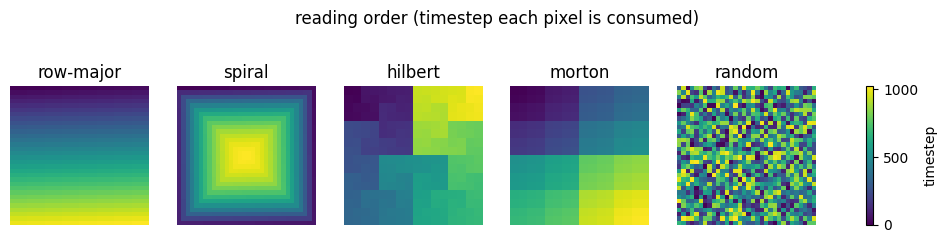

In [10]:
# Read order per pixel: dark = read first, bright = read last.
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
im = None
for ax, (name, index) in zip(axes, ORDERINGS.items()):
    omap = np.empty(N * N, dtype=np.int64); omap[index] = np.arange(N * N)
    im = ax.imshow(omap.reshape(N, N), cmap="viridis"); ax.set_title(name); ax.axis("off")
fig.suptitle("reading order (timestep each pixel is consumed)")
fig.colorbar(im, ax=axes, shrink=0.6, label="timestep")
plt.show()

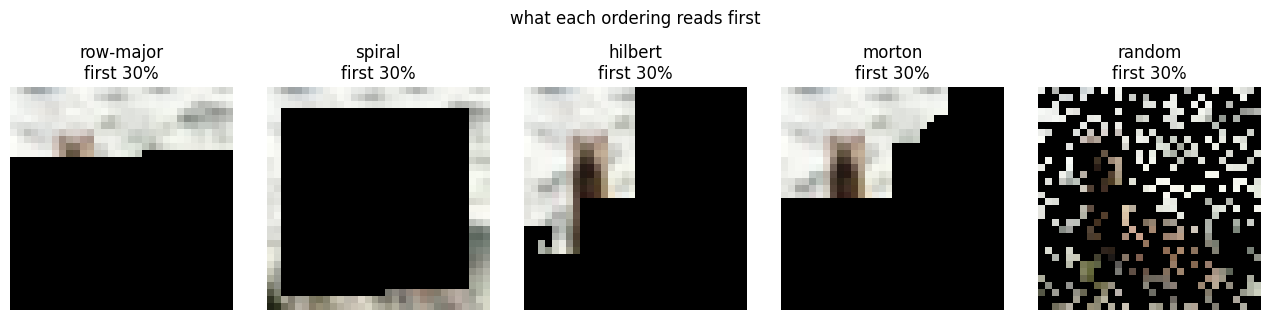

In [11]:
# What each ordering has "seen" after the first 30% of pixels, on one real image.
def reveal(img01, index, frac):
    out = img01.reshape(-1, 3).copy()
    keep = np.zeros(out.shape[0], dtype=bool); keep[index[:int(frac * index.shape[0])]] = True
    out[~keep] = 0.0
    return out.reshape(img01.shape)

sample = train_images[int(np.flatnonzero(train_coarse == 0)[0])].astype(np.float32) / 255.0
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, (name, index) in zip(axes, ORDERINGS.items()):
    ax.imshow(reveal(sample, index, 0.30)); ax.set_title(f"{name}\nfirst 30%"); ax.axis("off")
plt.suptitle("what each ordering reads first", y=1.05); plt.tight_layout(); plt.show()

## 6. LSTM Model

In [12]:
keras = tf.keras
layers = tf.keras.layers


def build_lstm(num_classes=NUM_CLASSES, hidden_units=HIDDEN, dropout=DROPOUT) -> keras.Model:
    """LSTM over (32, 96) -> softmax. tanh keeps the cuDNN fast path; dropout on the final state."""
    inputs = keras.Input(shape=(32, 96), name="sequence")
    x = layers.LSTM(hidden_units, activation="tanh")(inputs)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="probs")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="lstm")


build_lstm().summary()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence (InputLayer)           │ (None, 32, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,780 (460.08 KB)

 Trainable params: 117,780 (460.08 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train All Five

Same shared split, same architecture, **same weight initialization** (the seed is reset before each
build), same optimizer and callbacks. Only the pixel ordering varies across the loop.


In [13]:
img_tr, y_tr_s = stratified_subset(train_images, train_coarse, subset_size=SUBSET, seed=SEED)
x_tr, y_tr, x_val, y_val = stratified_train_val_split(img_tr, y_tr_s, val_fraction=0.1, seed=SEED)
print(f"shared split: train {x_tr.shape[0]}  val {x_val.shape[0]}  test {test_images.shape[0]}")

y_true = test_coarse.astype(np.int64)
labels20 = list(range(NUM_CLASSES))
results = {}

for order_name, index in ORDERINGS.items():
    print(f"\n{'='*56}\nTraining: {order_name}\n{'='*56}")
    train_ds = make_sequence_pipeline(x_tr, y_tr, index, batch_size=BATCH, shuffle=True, seed=SEED)
    val_ds   = make_sequence_pipeline(x_val, y_val, index, batch_size=BATCH, shuffle=False)
    test_ds  = make_sequence_pipeline(test_images, test_coarse, index, batch_size=BATCH, shuffle=False)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)      # identical initialization across all five
    model = build_lstm()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3")],
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)

    y_prob = model.predict(test_ds, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    cm = confusion_matrix(y_true, y_pred, labels=labels20)
    results[order_name] = {
        "history":   history.history,
        "top1":      accuracy_score(y_true, y_pred),
        "top3":      top_k_accuracy_score(y_true, y_prob, k=3, labels=labels20),
        "top5":      top_k_accuracy_score(y_true, y_prob, k=5, labels=labels20),
        "macro_f1":  f1_score(y_true, y_pred, average="macro", zero_division=0),
        "cm":        cm,
        "per_class": cm.diagonal() / cm.sum(axis=1).clip(min=1),
    }
    r = results[order_name]
    print(f"  {order_name}: top-1={r['top1']:.3f}  top-3={r['top3']:.3f}  macro-F1={r['macro_f1']:.3f}")

shared split: train 18000  val 2000  test 10000

Training: row-major
Epoch 1/30
141/141 - 15s - 110ms/step - accuracy: 0.1375 - loss: 2.7905 - top3: 0.3182 - val_accuracy: 0.2155 - val_loss: 2.5538 - val_top3: 0.4440 - learning_rate: 0.0010
Epoch 2/30
141/141 - 14s - 100ms/step - accuracy: 0.2056 - loss: 2.5564 - top3: 0.4301 - val_accuracy: 0.2400 - val_loss: 2.4766 - val_top3: 0.4660 - learning_rate: 0.0010
Epoch 3/30
141/141 - 17s - 117ms/step - accuracy: 0.2389 - loss: 2.4588 - top3: 0.4726 - val_accuracy: 0.2525 - val_loss: 2.4244 - val_top3: 0.4835 - learning_rate: 0.0010
Epoch 4/30
141/141 - 18s - 129ms/step - accuracy: 0.2602 - loss: 2.3798 - top3: 0.5012 - val_accuracy: 0.2845 - val_loss: 2.3423 - val_top3: 0.5260 - learning_rate: 0.0010
Epoch 5/30
141/141 - 20s - 144ms/step - accuracy: 0.2782 - loss: 2.3286 - top3: 0.5258 - val_accuracy: 0.2845 - val_loss: 2.3195 - val_top3: 0.5260 - learning_rate: 0.0010
Epoch 6/30
141/141 - 14s - 97ms/step - accuracy: 0.2913 - loss: 2.2869 

## 8. Compare — Learning Curves

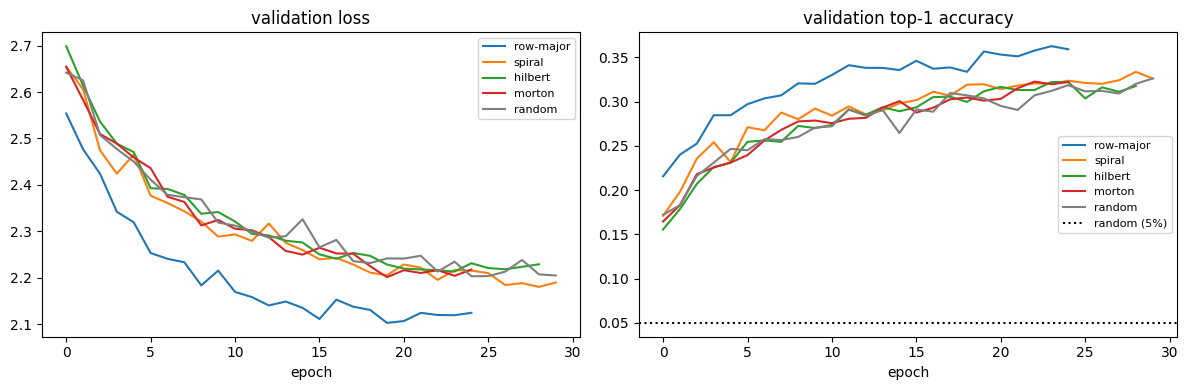

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, r in results.items():
    h = r["history"]
    ax[0].plot(h["val_loss"], color=PALETTE[name], label=name)
    ax[1].plot(h["val_accuracy"], color=PALETTE[name], label=name)
ax[0].set_title("validation loss"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=8)
ax[1].axhline(1 / NUM_CLASSES, color="black", ls=":", label="random (5%)")
ax[1].set_title("validation top-1 accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Compare — Test Metrics

ordering      top-1   top-3   top-5  macro-F1
---------------------------------------------
row-major     0.347   0.594   0.721     0.338
spiral        0.324   0.575   0.711     0.319
hilbert       0.317   0.568   0.705     0.308
morton        0.316   0.563   0.703     0.303
random        0.310   0.558   0.700     0.301


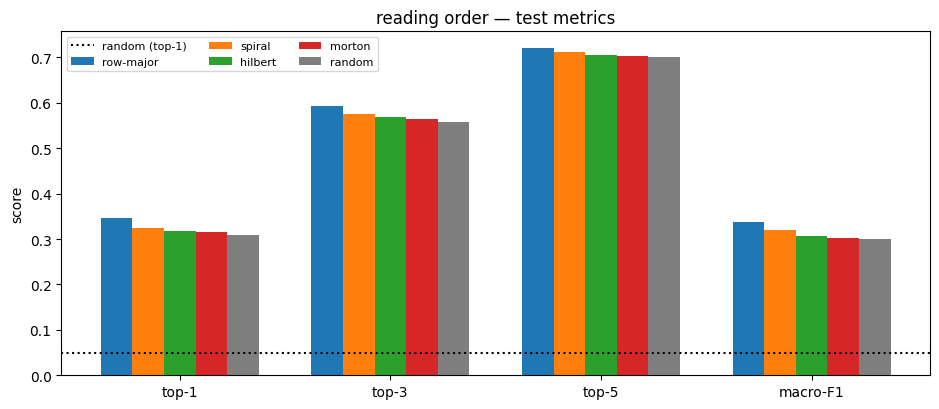

In [15]:
print(f"{'ordering':<11}{'top-1':>8}{'top-3':>8}{'top-5':>8}{'macro-F1':>10}")
print("-" * 45)
for name, r in sorted(results.items(), key=lambda kv: -kv[1]["top1"]):
    print(f"{name:<11}{r['top1']:>8.3f}{r['top3']:>8.3f}{r['top5']:>8.3f}{r['macro_f1']:>10.3f}")

metric_keys = ["top1", "top3", "top5", "macro_f1"]
metric_labels = ["top-1", "top-3", "top-5", "macro-F1"]
names = list(results.keys())
xs = np.arange(len(metric_keys)); width = 0.15
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for i, name in enumerate(names):
    vals = [results[name][k] for k in metric_keys]
    ax.bar(xs + (i - 2) * width, vals, width, label=name, color=PALETTE[name])
ax.axhline(1 / NUM_CLASSES, color="black", ls=":", label="random (top-1)")
ax.set_xticks(xs); ax.set_xticklabels(metric_labels); ax.set_ylabel("score")
ax.set_title("reading order — test metrics"); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

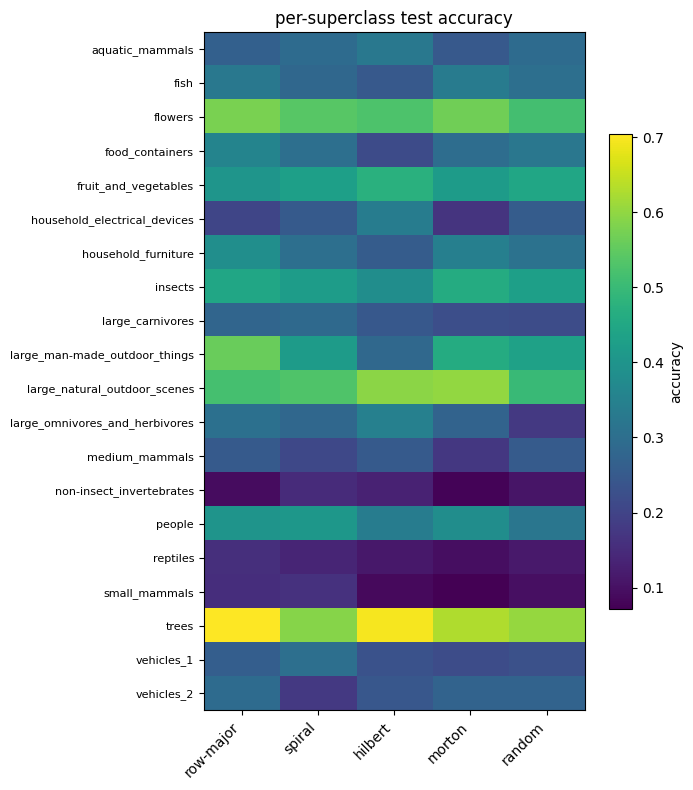

In [16]:
# Per-superclass accuracy: which ordering wins each class?
mat = np.stack([results[name]["per_class"] for name in results], axis=1)   # (20 classes, 5 orderings)
fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(mat, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(results))); ax.set_xticklabels(list(results.keys()), rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(coarse_names, fontsize=8)
ax.set_title("per-superclass test accuracy")
fig.colorbar(im, ax=ax, shrink=0.7, label="accuracy")
plt.tight_layout(); plt.show()

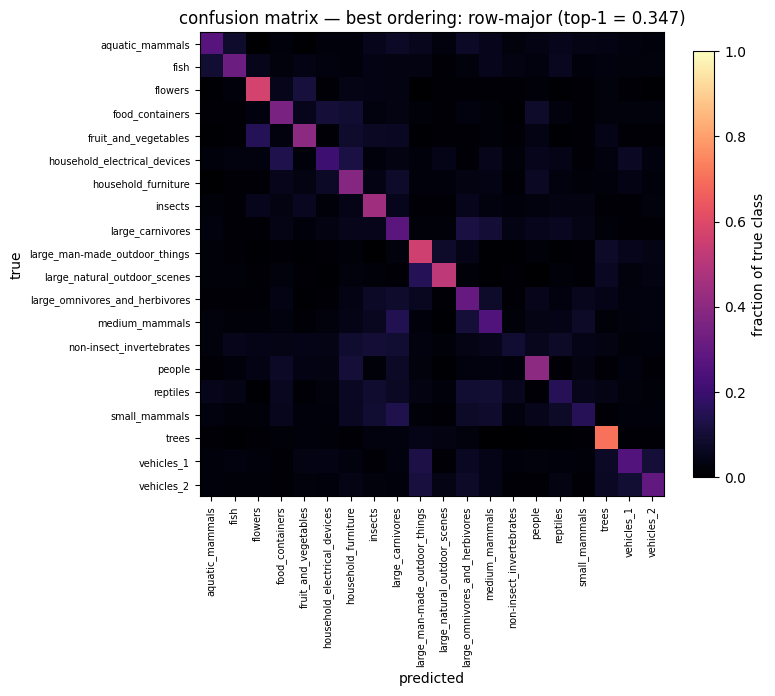

In [17]:
# Confusion matrix of the best ordering (by top-1), as a representative.
best = max(results, key=lambda n: results[n]["top1"])
cmn = results[best]["cm"] / results[best]["cm"].sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(8, 7))
plt.imshow(cmn, cmap="magma", vmin=0, vmax=1)
plt.colorbar(label="fraction of true class", shrink=0.85)
plt.xticks(range(NUM_CLASSES), coarse_names, rotation=90, fontsize=7)
plt.yticks(range(NUM_CLASSES), coarse_names, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title(f"confusion matrix — best ordering: {best} (top-1 = {results[best]['top1']:.3f})")
plt.tight_layout(); plt.show()

## Interpretation

The orderings are arranged by spatial locality (Section 5's spread table): hilbert ≈ morton (compact
timesteps) > row-major ≈ spiral (strips/arcs) > random (scattered). The hypothesis is that more local
orderings give the LSTM easier features to build, so you'd expect roughly **random < row-major ≈ spiral
< morton ≤ hilbert** in top-1 — and the gap between **random and the rest** is the cleanest single
measure of whether this LSTM uses spatial locality at all. If everything clusters near the same score,
that is itself the finding: a serialized-image LSTM is largely insensitive to order on this task.

The **morton vs hilbert** pair is the sharp control: they have equally compact timesteps but morton's
*path* makes long jumps between them, so a hilbert-over-morton gap points to the macro-trajectory
mattering, not just per-timestep compactness. The per-superclass heatmap shows where each ordering
earns its keep; the confusion matrix shows what the best one still confuses.

Caveat for the writeup: this is one seed — one run, not a significance test. Before claiming any ranking
is real, rerun with a few `SEED` values and confirm the gaps survive the noise.
